In [20]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


In [21]:
plt.rcParams["font.family"] = "Arial Unicode MS"
random.seed(42)

In [22]:
IMG_DICT = {}
IMG_DIR = "lowercase_characters"

for i, character in enumerate("abcdefghijklmnopqrstuvwxyz"):
    IMG_DICT[character] = [
        f"{character}/{img}" for img in os.listdir(f"lowercase_characters/{character}")
    ]
    print(
        f"{character}: "
        f"{sum(1 for _ in IMG_DICT[character])}"
    )

a: 30
b: 30
c: 30
d: 30
e: 30
f: 30
g: 30
h: 30
i: 30
j: 30
k: 30
l: 30
m: 30
n: 30
o: 30
p: 30
q: 30
r: 30
s: 30
t: 30
u: 30
v: 30
w: 30
x: 30
y: 30
z: 30


In [23]:
def display_sample_images(img_dict, img_dir):
    fig, axes = plt.subplots(5, 5, figsize=(6, 6))

    for row, character in enumerate(list(img_dict.keys())[:5]):
        imgs = img_dict[character]

        sample_imgs = random.sample(imgs, 5)

        for col in range(5):
            ax = axes[row][col]
            ax.axis("off")

            img_path = os.path.join(img_dir, sample_imgs[col])
            img = Image.open(img_path)

            ax.imshow(img, cmap="gray")

    plt.tight_layout()
    plt.show()

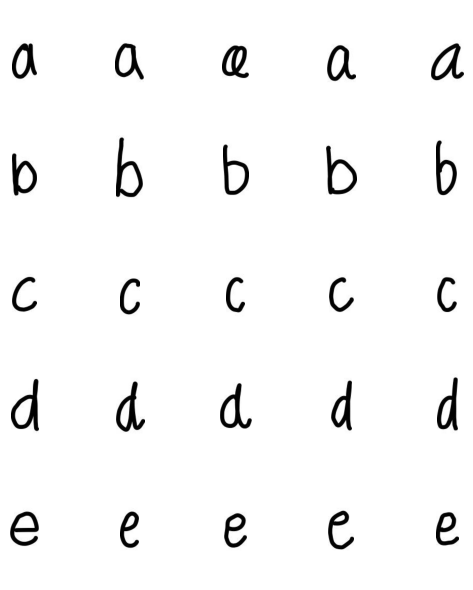

In [24]:
display_sample_images(IMG_DICT, IMG_DIR)

In [25]:
def process_character(img_path):
    img = Image.open(img_path).convert("L")
    arr = np.array(img)

    arr = arr < 128

    return arr

def pad_to_width(arr, target_width):
    h, w = arr.shape

    if w == target_width:
        return arr

    total_padding = target_width - w
    left_padding = total_padding // 2
    right_padding = total_padding - left_padding

    padded = np.pad(
        arr,
        pad_width=((0, 0), (left_padding, right_padding)),
        mode="constant",
        constant_values=0
    )

    return padded

In [26]:
def process_language(img_dict, img_dir):
    processed_img_dict = {}

    for character in img_dict:
        imgs = []

        for img_name in img_dict[character]:
            img_path = os.path.join(img_dir, img_name)
            final_img = process_character(img_path)
            imgs.append(final_img)

        max_width = max(img.shape[1] for img in imgs)

        padded_imgs = []

        for img in imgs:
            padded_img = pad_to_width(img, max_width)
            padded_imgs.append(padded_img)

        processed_img_dict[character] = padded_imgs

    return processed_img_dict

def display_sample_processed_images(processed_img_dict):
    fig, axes = plt.subplots(5, 5, figsize=(6, 6))

    for row, character in enumerate(list(processed_img_dict.keys())[:5]):
        imgs = processed_img_dict[character]
        sample_imgs = random.sample(imgs, 5)

        for col in range(5):
            ax = axes[row][col]
            ax.axis("off")

            ax.imshow(sample_imgs[col], cmap="gray")

    plt.tight_layout()
    plt.show()

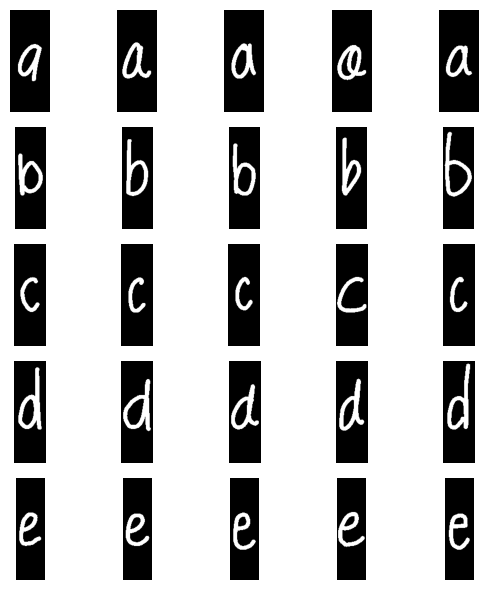

In [27]:
processed_img_dict = process_language(IMG_DICT, IMG_DIR)
display_sample_processed_images(processed_img_dict)

In [28]:
def calculate_mean_image(processed_img_dict):
    mean_img_dict = {}

    for character, imgs in processed_img_dict.items():
        mean_img = np.mean(imgs, axis=0)
        max_val = np.max(mean_img)
        mean_img = mean_img / max_val
        
        mean_img_dict[character] = mean_img

    return mean_img_dict

def display_mean_images(mean_img_dict):
    fig, axes = plt.subplots(5, 6, figsize=(6, 6))
    axes = axes.flatten()

    for i, character in enumerate(list(mean_img_dict.keys())):
        axes[i].imshow(mean_img_dict[character], cmap="gray_r", vmin=0, vmax=1)
        axes[i].set_title(character)
        axes[i].axis("off")

    for i in range(30):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

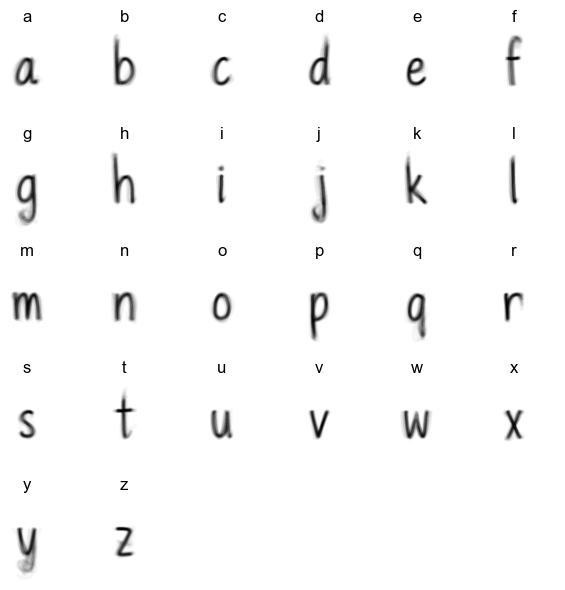

In [29]:
mean_img_dict = calculate_mean_image(processed_img_dict)
display_mean_images(mean_img_dict)

In [30]:
def calculate_variation(processed_img_dict, mean_img_dict, active_threshold=0.1):
    variation_dict = {}

    for character in processed_img_dict:
        mean_img = mean_img_dict[character]
        active_region = mean_img > active_threshold

        scores = []

        for img in processed_img_dict[character]:
            score = np.mean((img[active_region] - mean_img[active_region]) ** 2)
            scores.append(score)

        variation_dict[character] = np.mean(scores)

    return variation_dict

def display_variation(variation_dict):
    characters = list(variation_dict.keys())
    scores = list(variation_dict.values())

    plt.figure(figsize=(12, 6))
    plt.bar(characters, scores)
    plt.xlabel("Character")
    plt.ylabel("Average Squared Deviation")
    plt.title("Variation of Handwriting for Each Character")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

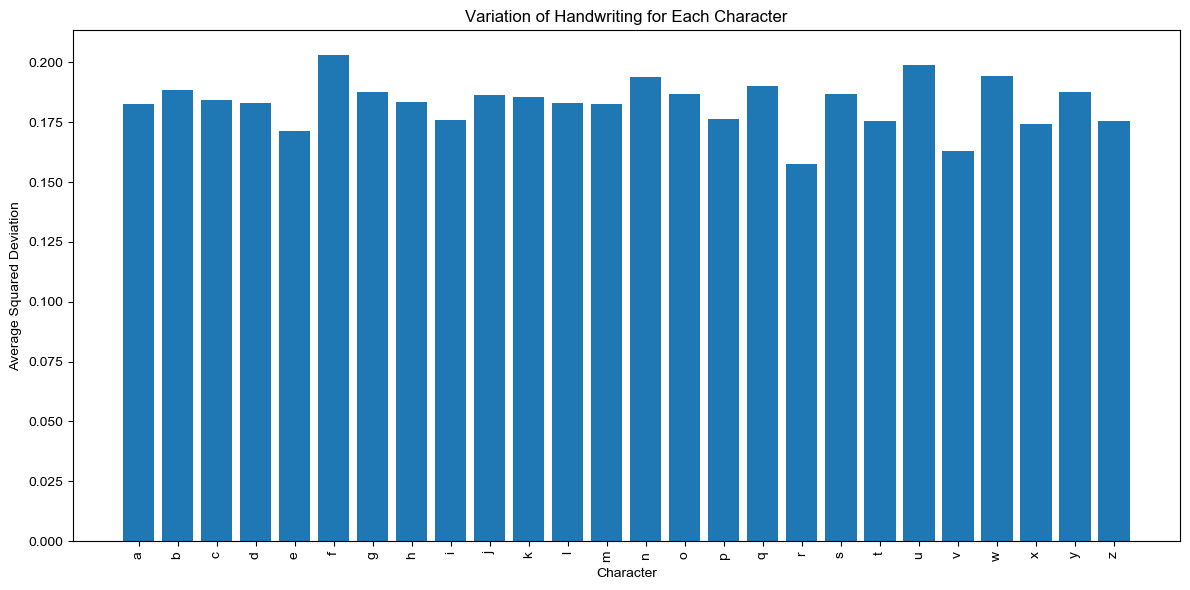

In [31]:
scores = calculate_variation(processed_img_dict, mean_img_dict)
display_variation(scores)

In [32]:
print("Average variation:", np.mean(list(scores.values())))
print("Standard deviation variation:", np.std(list(scores.values())))

Average variation: 0.18295143617238804
Standard deviation variation: 0.009890457643917513
